# Propagation in Free Space

In this example, we will simulate the propagation of an electromagnetic wave in free space using several propagation methods based on the angular spectrum approach. We will compare the results of these methods to understand their differences and applications.

In [1]:
import torch

from svetlanna.elements import FreeSpace
from svetlanna import SimulationParameters
from svetlanna import Wavefront
from svetlanna.units import ureg

import matplotlib.pyplot as plt

First, we will define the parameters for our simulation, including the wavelength of the wavefront, the size of the computational grid, and the distance over which we want to propagate the wave

In [2]:
lx = 6 * ureg.mm  # size along x-axis
ly = 6 * ureg.mm  # size along y-axis
Nx = 1300  # number of nodes along x-axis
Ny = 1300  # number of nodes along y-axis

dx = lx / Nx  # step along x-axis
dy = ly / Ny  # step along y-axis

z = 10 * ureg.mm  # propagation distance, mm

wl = 1064 * ureg.nm  # wavelength of the wavefront, nm

params = SimulationParameters(
    {
        "x": torch.linspace(-lx / 2, lx / 2, Nx),
        "y": torch.linspace(-ly / 2, ly / 2, Ny),
        "wavelength": wl,
    }
)

x_grid, y_grid = params.meshgrid(x_axis="W", y_axis="H")  # create computational grid

Secondly, we will create a Gaussian beam as our initial wavefront. The Gaussian beam is a common model for laser beams and is characterized by its waist radius and wavelength

In [3]:
w0 = 1 * ureg.mm  # waist radius of the Gaussian beam, mm
initial_wavefront = Wavefront.gaussian_beam(
    simulation_parameters=params, waist_radius=w0
)  # create Gaussian beam as initial wavefront

initial_wavefront_intensity = initial_wavefront.intensity

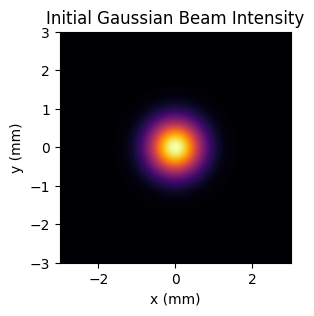

In [4]:
fig, ax = plt.subplots(figsize=(3, 3))

ax.pcolormesh(
    x_grid * 1000,
    y_grid * 1000,
    initial_wavefront_intensity,
    shading="auto",
    cmap="inferno",
)
ax.set_xlabel("x (mm)")
ax.set_ylabel("y (mm)")
ax.set_title("Initial Gaussian Beam Intensity")
ax.set_aspect("equal")

Thirdly, we will set up the propagation methods we want to use for simulating the wavefront propagation. We will use the Angular Spectrum Method (ASM), Zero-Padded Angular Spectrum Method (zpASM), Rayleigh-Sommerfeld Convolution (RSC), and Zero-Padded Rayleigh-Sommerfeld Convolution (zpRSC).

c:\Users\gunne\projects\python\dnn\SVETlANNa\svetlanna\elements\free_space.py:356: UserWarning: In the ASM aliasing problems may occur. Consider reducing the distance or increasing the Nx*dx product or using zpAS method.
  warn(x_message)
c:\Users\gunne\projects\python\dnn\SVETlANNa\svetlanna\elements\free_space.py:358: UserWarning: In the ASM aliasing problems may occur. Consider reducing the distance or increasing the Ny*dy product or using zpAS method.
  warn(y_message)
c:\Users\gunne\projects\python\dnn\SVETlANNa\svetlanna\elements\free_space.py:356: UserWarning: In RSC method propagation distance is not large enough in the x direction.It is preferable to use the zpASM or ASM method.
  warn(x_message)
c:\Users\gunne\projects\python\dnn\SVETlANNa\svetlanna\elements\free_space.py:358: UserWarning: In RSC method propagation distance is not large enough in the y direction.It is preferable to use the zpASM or ASM method.
  warn(y_message)
c:\Users\gunne\projects\python\dnn\SVETlANNa\sve

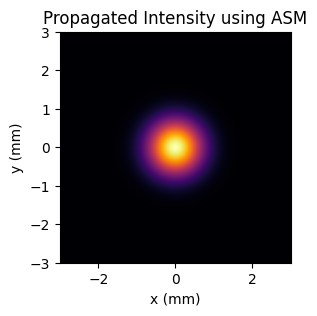

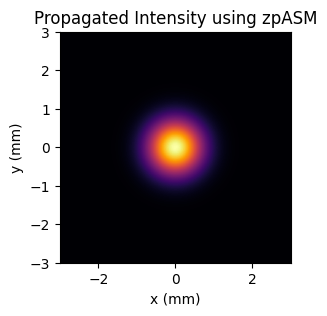

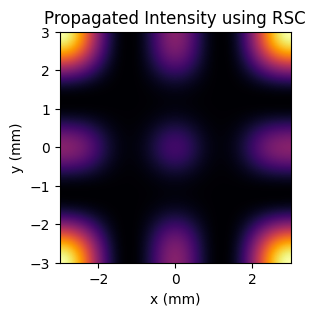

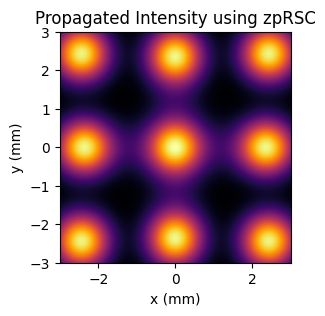

In [5]:
methods = ["ASM", "zpASM", "RSC", "zpRSC"]

intensities = {}

for method in methods:
    free_space = FreeSpace(simulation_parameters=params, distance=z, method=method)
    propagated_wavefront = free_space.forward(initial_wavefront)

    propagated_intensity = propagated_wavefront.intensity
    intensities[method] = propagated_intensity

    fig, ax = plt.subplots(figsize=(3, 3))
    ax.pcolormesh(
        x_grid * 1000,
        y_grid * 1000,
        propagated_intensity,
        shading="auto",
        cmap="inferno",
    )
    ax.set_xlabel("x (mm)")
    ax.set_ylabel("y (mm)")
    ax.set_title(f"Propagated Intensity using {method}")
    ax.set_aspect("equal")

Text(0.5, 1.0, 'Intensity Profiles at y=0')

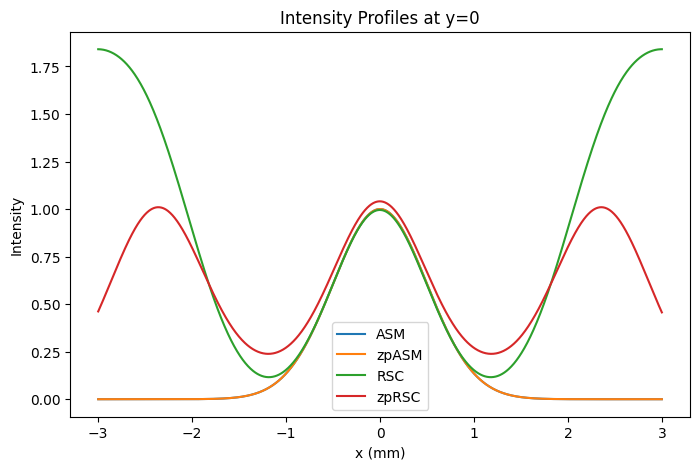

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

middle_index = Ny // 2

for method in methods:
    ax.plot(
        x_grid[middle_index] * 1000,
        intensities[method][middle_index],
        label=method,
    )

ax.set_xlabel("x (mm)")
ax.set_ylabel("Intensity")
ax.legend()
ax.set_title("Intensity Profiles at y=0")
# ax.set_aspect("equal")

We can see that the results of the propagation methods are different. Furthermore, for ASM, RSC and zpRSC methods warnings are raised due to the fact that the propagated wavefront is not fully contained within the computational grid and distance parameter, which can lead to inaccuracies in the results. Only the zpASM method does not raise a warning, indicating that it is the most suitable method for this particular simulation setup. This highlights the importance of choosing the appropriate propagation method based on the specific parameters and requirements of the simulation.

zpRSC and RSC methods are more accurate on the large distances, whereas ASM and zpASM methods are more accurate on the near field.